In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('datos_curados.csv')
df

,Localidad,Cultivar,Repetición,α Tocopherol,γ Tocopherol,δ Tocopherol,α+γ+δ Tocopherol,Palmitic Acid,Palmitoleic Acid,Stearic Acid,...,inicio de floración IF,Madurez fisiologica MF,Dur S-IF,Dur S-MF,Dur IF-MF,Tmx IF-MF,Tmed IF-MF,T mn IF-MF,pp IF-MF,etp IF- MF
0,Loc_1,cv_1,1,502.64,826.36,6.18,1335.18,4.26,0.20,2.04,...,2012-10-04,2012-11-26,157,211,54,29.9,23.05,17.1,214.0,222.8
1,Loc_1,cv_1,2,511.20,788.10,7.36,1306.66,4.24,0.20,1.96,...,2012-10-04,2012-11-26,157,211,54,29.9,23.05,17.1,214.0,222.8
2,Loc_1,cv_2,1,317.95,726.27,0.00,1044.22,3.96,0.17,1.89,...,2012-09-29,2012-11-25,152,210,58,28.7,21.70,15.0,214.9,232.1
3,Loc_1,cv_2,2,356.28,796.46,7.22,1159.96,4.45,0.19,2.21,...,2012-09-29,2012-11-25,152,210,58,28.7,21.70,15.0,214.9,232.1
4,Loc_1,cv_3,1,405.68,745.75,3.79,1155.22,4.17,0.17,1.95,...,2012-09-23,2012-11-17,146,202,56,28.7,21.70,15.0,185.3,225.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Loc_4,cv_11,2,301.55,529.71,10.12,841.38,3.90,0.13,1.95,...,2012-09-18,2012-11-18,126,187,62,21.3,15.00,8.7,0.0,196.0
100,Loc_4,cv_12,1,307.06,558.40,1.97,867.43,4.01,0.20,2.06,...,2012-09-13,2012-11-15,121,184,64,21.3,14.90,8.5,0.0,196.9
101,Loc_4,cv_12,2,321.44,631.59,4.95,957.98,3.96,0.16,1.59,...,2012-09-13,2012-11-15,121,184,64,21.3,14.90,8.5,0.0,196.9
102,Loc_4,cv_13,1,284.28,621.01,7.25,912.54,3.94,0.18,2.06,...,2012-09-12,2012-11-15,120,184,65,21.3,14.90,8.4,0.0,194.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Localidad               104 non-null    object 
 1   Cultivar                104 non-null    object 
 2   Repetición              104 non-null    int64  
 3   α Tocopherol            104 non-null    float64
 4   γ Tocopherol            104 non-null    float64
 5   δ Tocopherol            104 non-null    float64
 6   α+γ+δ Tocopherol        104 non-null    float64
 7   Palmitic Acid           104 non-null    float64
 8   Palmitoleic Acid        104 non-null    float64
 9   Stearic Acid            104 non-null    float64
 10  Oleic Acid              104 non-null    float64
 11  Linoleic Acid           104 non-null    float64
 12  Linolenic Acid          104 non-null    float64
 13  Arachidic Acid          104 non-null    float64
 14  Ecosenoic Acid          104 non-null    fl

1) ¿Cuáles cultivares de colza presentan mayor contenido de ácido linolénico y menor contenido
de ácidos grasos saturados?

In [ ]:
df_1 = df.copy()
df_1 = df_1[['Cultivar', 'Linolenic Acid',
           'Palmitic Acid', 'Palmitoleic Acid',
           'Stearic Acid', 'Arachidic Acid']]

In [ ]:
df_1['Saturated Acids'] = df_1['Palmitic Acid'] + df_1['Palmitoleic Acid'] + df_1['Stearic Acid'] + df_1['Arachidic Acid']
df_1

,Cultivar,Linolenic Acid,Palmitic Acid,Palmitoleic Acid,Stearic Acid,Arachidic Acid,Saturated Acids
0,cv_1,7.11,4.26,0.20,2.04,0.44,6.94
1,cv_1,7.01,4.24,0.20,1.96,0.51,6.91
2,cv_2,7.92,3.96,0.17,1.89,0.48,6.50
3,cv_2,7.51,4.45,0.19,2.21,0.41,7.26
4,cv_3,7.04,4.17,0.17,1.95,0.31,6.60
...,...,...,...,...,...,...,...
99,cv_11,8.10,3.90,0.13,1.95,0.25,6.23
100,cv_12,7.94,4.01,0.20,2.06,0.54,6.81
101,cv_12,8.86,3.96,0.16,1.59,0.41,6.12
102,cv_13,8.15,3.94,0.18,2.06,0.54,6.72


In [ ]:
df_1.columns

Index(['Cultivar', 'Linolenic Acid', 'Palmitic Acid', 'Palmitoleic Acid',
       'Stearic Acid', 'Arachidic Acid', 'Saturated Acids'],
      dtype='object')

In [ ]:
df_1_mean = df_1.copy().groupby(['Cultivar'], as_index=False).mean(numeric_only=True)
df_1_std = df_1.copy().groupby(['Cultivar'], as_index=False).std(ddof=1)
df_1_mean = df_1_mean.drop(['Palmitic Acid', 'Palmitoleic Acid',
       'Stearic Acid', 'Arachidic Acid'], axis = 1)
df_1_std

,Cultivar,Linolenic Acid,Palmitic Acid,Palmitoleic Acid,Stearic Acid,Arachidic Acid,Saturated Acids
0,cv_1,0.869720,0.267044,0.071602,0.462601,0.119754,0.783517
1,cv_10,0.738507,0.168353,0.020659,0.127167,0.141869,0.287737
2,cv_11,0.871779,0.241838,0.057181,0.318108,0.121155,0.538846
3,cv_12,0.909411,0.119276,0.021381,0.224400,0.138873,0.339664
4,cv_13,0.910114,0.165249,0.053835,0.159816,0.150375,0.250225
5,cv_2,0.846251,0.249768,0.011952,0.169869,0.173488,0.431821
6,cv_3,0.835360,0.194643,0.024165,0.224877,0.159726,0.276454
7,cv_4,0.820191,0.231328,0.023867,0.285704,0.308635,0.386551
8,cv_5,0.742871,0.348094,0.029641,0.184850,0.153320,0.521755
9,cv_6,0.917668,0.166562,0.027484,0.170666,0.173699,0.341677


In [ ]:
for col in df_1_mean.columns.difference(['Cultivar']):
    error_colum = f'{col}_error'
    df_1_mean[error_colum] = df_1_std[col] * 0.836

df_1_mean

,Cultivar,Linolenic Acid,Saturated Acids,Linolenic Acid_error,Saturated Acids_error
0,cv_1,8.06125,6.76875,0.727086,0.655020
1,cv_10,8.40250,6.45750,0.617392,0.240549
2,cv_11,8.41375,6.47125,0.728807,0.450476
3,cv_12,8.45000,6.26000,0.760268,0.283959
4,cv_13,8.47250,6.42875,0.760855,0.209188
5,cv_2,8.85625,6.46875,0.707466,0.361003
6,cv_3,8.14375,6.47375,0.698361,0.231116
7,cv_4,8.51625,6.62750,0.685679,0.323156
8,cv_5,8.63500,6.56500,0.621040,0.436187
9,cv_6,8.44000,6.55500,0.767170,0.285642


<Figure size 1000x600 with 0 Axes>

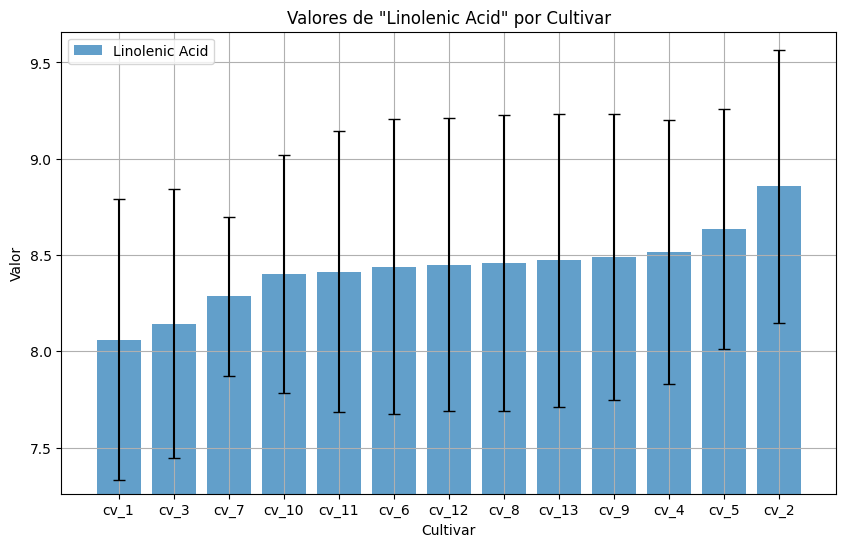

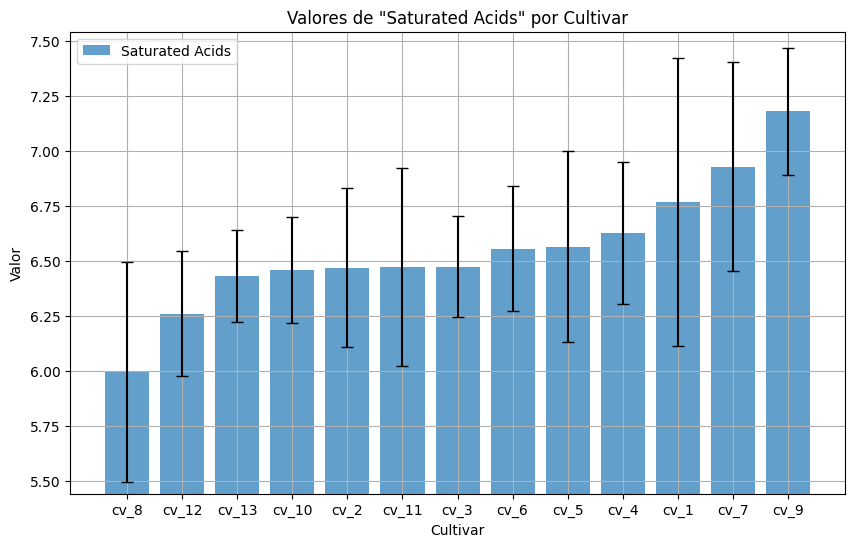

In [ ]:
# Definir las columnas de interés y sus respectivos errores
columns = ['Linolenic Acid', 'Saturated Acids']
error_columns = ['Linolenic Acid_error', 'Saturated Acids_error']

# Crear la gráfica
plt.figure(figsize=(10, 6))

for col, err_col in zip(columns, error_columns):

    df_sorted = df_1_mean.sort_values(by=col, ascending=True)

    plt.figure(figsize=(10, 6))
    x = df_sorted['Cultivar']
    x_ticks = range(len(x))
    y = df_sorted[col]

    error = df_sorted[err_col]
    y_upper_limit = max(y + error) * 1.01
    y_lower_limit = min(y - error) * 0.99

    plt.bar(x_ticks, y, yerr=error, label=col, capsize=4, alpha=0.7)

    plt.xlabel('Cultivar')
    plt.ylabel('Valor')
    plt.title(f'Valores de "{col}" por Cultivar')
    plt.xticks(x_ticks, x)

    plt.ylim(y_lower_limit, y_upper_limit)

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
df_1_mean['Diff'] = df_1_mean['Linolenic Acid'] - df_1_mean['Saturated Acids']
df_1_mean['Diff_error'] = df_1_mean['Linolenic Acid_error'] + df_1_mean['Saturated Acids_error']
df_1_mean

,Cultivar,Linolenic Acid,Saturated Acids,Linolenic Acid_error,Saturated Acids_error,Diff,Diff_error
0,cv_1,8.06125,6.76875,0.727086,0.655020,1.29250,1.382106
1,cv_10,8.40250,6.45750,0.617392,0.240549,1.94500,0.857941
2,cv_11,8.41375,6.47125,0.728807,0.450476,1.94250,1.179283
3,cv_12,8.45000,6.26000,0.760268,0.283959,2.19000,1.044227
4,cv_13,8.47250,6.42875,0.760855,0.209188,2.04375,0.970043
5,cv_2,8.85625,6.46875,0.707466,0.361003,2.38750,1.068469
6,cv_3,8.14375,6.47375,0.698361,0.231116,1.67000,0.929477
7,cv_4,8.51625,6.62750,0.685679,0.323156,1.88875,1.008836
8,cv_5,8.63500,6.56500,0.621040,0.436187,2.07000,1.057227
9,cv_6,8.44000,6.55500,0.767170,0.285642,1.88500,1.052812


<Figure size 1000x600 with 0 Axes>

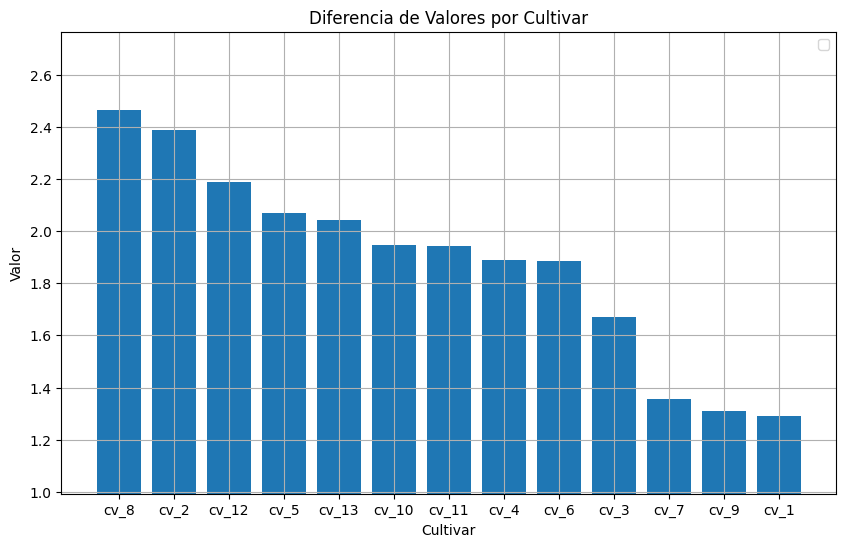

In [ ]:
plt.figure(figsize=(10, 6))

df_sorted = df_1_mean.sort_values(by='Diff', ascending=False)

plt.figure(figsize=(10, 6))
x = df_sorted['Cultivar']
x_ticks = range(len(x))
y = df_sorted['Diff']

#error = df_sorted['Diff_error']
y_upper_limit = max(y + 0.3)#error) * 1.1
y_lower_limit = min(y - 0.3)#error) * 0.5

plt.bar(x_ticks, y)# yerr=error, label=col, capsize=4, alpha=0.7)

plt.xlabel('Cultivar')
plt.ylabel('Valor')
plt.title(f'Diferencia de Valores por Cultivar')
plt.xticks(x_ticks, x)

plt.ylim(y_lower_limit, y_upper_limit)

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison

groups = df_1['Cultivar'].unique()
data = {group: df_1[df_1['Cultivar'] == group]['Linolenic Acid'] for group in groups}

f_statistic, p_value = f_oneway(*data.values())

mc = MultiComparison(df_1['Linolenic Acid'], df_1['Cultivar'])
result = mc.tukeyhsd()
print(result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  cv_1  cv_10   0.3413 0.9998 -1.0806 1.7631  False
  cv_1  cv_11   0.3525 0.9997 -1.0693 1.7743  False
  cv_1  cv_12   0.3887 0.9993 -1.0331 1.8106  False
  cv_1  cv_13   0.4112 0.9987 -1.0106 1.8331  False
  cv_1   cv_2    0.795 0.7896 -0.6268 2.2168  False
  cv_1   cv_3   0.0825    1.0 -1.3393 1.5043  False
  cv_1   cv_4    0.455 0.9967 -0.9668 1.8768  False
  cv_1   cv_5   0.5738 0.9757 -0.8481 1.9956  False
  cv_1   cv_6   0.3788 0.9994 -1.0431 1.8006  False
  cv_1   cv_7   0.2238    1.0 -1.1981 1.6456  False
  cv_1   cv_8   0.3975 0.9991 -1.0243 1.8193  False
  cv_1   cv_9   0.4275 0.9982 -0.9943 1.8493  False
 cv_10  cv_11   0.0113    1.0 -1.4106 1.4331  False
 cv_10  cv_12   0.0475    1.0 -1.3743 1.4693  False
 cv_10  cv_13     0.07    1.0 -1.3518 1.4918  False
 cv_10   cv_2   0.4537 0.9968 -0.9681 1.8756  False
 cv_10   cv_

In [ ]:
groups = df_1['Cultivar'].unique()
data = {group: df_1[df_1['Cultivar'] == group]['Saturated Acids'] for group in groups}

f_statistic, p_value = f_oneway(*data.values())

mc = MultiComparison(df_1['Saturated Acids'], df_1['Cultivar'])
result = mc.tukeyhsd()
print(result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  cv_1  cv_10  -0.3113 0.9787 -1.0954  0.4729  False
  cv_1  cv_11  -0.2975 0.9852 -1.0817  0.4867  False
  cv_1  cv_12  -0.5088 0.5885 -1.2929  0.2754  False
  cv_1  cv_13    -0.34  0.958 -1.1242  0.4442  False
  cv_1   cv_2     -0.3 0.9842 -1.0842  0.4842  False
  cv_1   cv_3   -0.295 0.9862 -1.0792  0.4892  False
  cv_1   cv_4  -0.1413    1.0 -0.9254  0.6429  False
  cv_1   cv_5  -0.2038 0.9996 -0.9879  0.5804  False
  cv_1   cv_6  -0.2138 0.9993 -0.9979  0.5704  False
  cv_1   cv_7     0.16    1.0 -0.6242  0.9442  False
  cv_1   cv_8   -0.775 0.0559 -1.5592  0.0092  False
  cv_1   cv_9   0.4113 0.8522 -0.3729  1.1954  False
 cv_10  cv_11   0.0137    1.0 -0.7704  0.7979  False
 cv_10  cv_12  -0.1975 0.9997 -0.9817  0.5867  False
 cv_10  cv_13  -0.0287    1.0 -0.8129  0.7554  False
 cv_10   cv_2   0.0113    1.0 -0.7729  0.7954 

In [ ]:
from itertools import combinations
from scipy.stats import ttest_ind

# Columnas para comparar
columns_to_compare = ['Linolenic Acid','Saturated Acids']

for col in columns_to_compare:
    print(f"Comparación para la columna {col}:")
    print("=" * 50)

    # Realizar todas las combinaciones posibles de comparación entre categorías
    category_combinations = combinations(df_1['Cultivar'].unique(), 2)

    for category1, category2 in category_combinations:
        values_category1 = df_1[df_1['Cultivar'] == category1][col]
        values_category2 = df_1[df_1['Cultivar'] == category2][col]

        # Calcular la prueba t de Student
        t_statistic, p_value = ttest_ind(values_category1, values_category2, equal_var=False)

        if p_value < 0.05:
            print(f"Hay diferencia significativa en la columna {col} entre {category1} y {category2}.")

    print("=" * 50)


Comparación para la columna Linolenic Acid:
Comparación para la columna Saturated Acids:
Hay diferencia significativa en la columna Saturated Acids entre cv_1 y cv_8.
Hay diferencia significativa en la columna Saturated Acids entre cv_2 y cv_9.
Hay diferencia significativa en la columna Saturated Acids entre cv_3 y cv_9.
Hay diferencia significativa en la columna Saturated Acids entre cv_4 y cv_8.
Hay diferencia significativa en la columna Saturated Acids entre cv_4 y cv_9.
Hay diferencia significativa en la columna Saturated Acids entre cv_5 y cv_9.
Hay diferencia significativa en la columna Saturated Acids entre cv_6 y cv_8.
Hay diferencia significativa en la columna Saturated Acids entre cv_6 y cv_9.
Hay diferencia significativa en la columna Saturated Acids entre cv_7 y cv_8.
Hay diferencia significativa en la columna Saturated Acids entre cv_7 y cv_12.
Hay diferencia significativa en la columna Saturated Acids entre cv_7 y cv_13.
Hay diferencia significativa en la columna Saturate

In [ ]:
df_1['Diff'] = df_1['Linolenic Acid'] - df_1['Saturated Acids']
df_1

,Cultivar,Linolenic Acid,Palmitic Acid,Palmitoleic Acid,Stearic Acid,Arachidic Acid,Saturated Acids,Diff
0,cv_1,7.11,4.26,0.20,2.04,0.44,6.94,0.17
1,cv_1,7.01,4.24,0.20,1.96,0.51,6.91,0.10
2,cv_2,7.92,3.96,0.17,1.89,0.48,6.50,1.42
3,cv_2,7.51,4.45,0.19,2.21,0.41,7.26,0.25
4,cv_3,7.04,4.17,0.17,1.95,0.31,6.60,0.44
...,...,...,...,...,...,...,...,...
99,cv_11,8.10,3.90,0.13,1.95,0.25,6.23,1.87
100,cv_12,7.94,4.01,0.20,2.06,0.54,6.81,1.13
101,cv_12,8.86,3.96,0.16,1.59,0.41,6.12,2.74
102,cv_13,8.15,3.94,0.18,2.06,0.54,6.72,1.43


In [ ]:
print(f"Comparación para la columna 'Diff':")
print("=" * 50)

# Realizar todas las combinaciones posibles de comparación entre categorías
category_combinations = combinations(df_1['Cultivar'].unique(), 2)

for category1, category2 in category_combinations:
    values_category1 = df_1[df_1['Cultivar'] == category1]['Diff']
    values_category2 = df_1[df_1['Cultivar'] == category2]['Diff']

    # Calcular la prueba t de Student
    t_statistic, p_value = ttest_ind(values_category1, values_category2, equal_var=False)

    if p_value < 0.05:
        print(f"Hay diferencia significativa en la columna 'Diff' entre {category1} y {category2}.")

Comparación para la columna 'Diff':
